# 04. GARCH(1,1) 변동성 예측

## 목적
매월 말 기준, 다음 달 개별 종목 월별 실현변동성(`vol_21d`) 예측

## 설계
- 모델: **GARCH(1,1)** — 03 EDA에서 ARCH 효과 85% 유의 확인
- 입력: 직전 60개월 월별 수익률
- 타겟: 다음 달 `vol_21d` (연환산)
- 검증: Rank IC (Spearman) — 03의 AR(1) R² 중앙값 0.235와 비교
- 출력: `data/vol_predicted.csv` — (date, ticker, vol_pred)

In [ ]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings, time, platform
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '04_garch'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_WINDOW = 60
MIN_OBS      = 36
START_PRED   = '2011-01-01'
ANN          = np.sqrt(12)

panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])
ret_pivot = panel['ret_1m'].unstack('ticker')
vol_pivot = panel['vol_21d'].unstack('ticker')

all_dates  = ret_pivot.index.sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

# GARCH(1,1) 예측 함수

In [2]:
def predict_garch(r, min_obs=MIN_OBS):
    """
    GARCH(1,1) 1-step ahead 연환산 변동성 예측
    수렴 실패 또는 데이터 부족 시 역사적 변동성으로 대체
    """
    r = r.dropna() * 100  # percent 스케일 (수치 안정성)
    if len(r) < min_obs:
        return float(r.std() * ANN / 100)
    try:
        am  = arch_model(r, vol='Garch', p=1, q=1, dist='normal', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        fc  = res.forecast(horizon=1, reindex=False)
        return float(np.sqrt(fc.variance.values[0, 0]) * ANN / 100)
    except Exception:
        return float(r.std() * ANN / 100)

print('GARCH(1,1) 함수 정의 완료')
print(f'예상 소요 시간: 30~90분 (CPU 환경에 따라 다름)')

GARCH(1,1) 함수 정의 완료
예상 소요 시간: 30~90분 (CPU 환경에 따라 다름)


# Walk-forward 예측 루프

In [3]:
t0 = time.time()
all_records = []
n_fallback  = 0

print(f'GARCH(1,1) Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
    train_ret   = ret_pivot.reindex(index=train_dates)

    if pred_date not in vol_pivot.index:
        continue
    universe = vol_pivot.loc[pred_date].dropna().index.tolist()

    for ticker in universe:
        if ticker in train_ret.columns:
            vol_pred = predict_garch(train_ret[ticker])
        else:
            vol_pred = np.nan
            n_fallback += 1
        all_records.append({'date': pred_date, 'ticker': ticker, 'vol_pred': vol_pred})

    if (i + 1) % 12 == 0:
        elapsed = time.time() - t0
        eta     = elapsed / (i + 1) * (len(pred_dates) - i - 1)
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)}) '
              f'— 경과 {elapsed/60:.1f}분, 잔여 {eta/60:.1f}분')

print(f'\n완료: {(time.time()-t0)/60:.1f}분  |  예측 {len(all_records):,}개  |  fallback {n_fallback}개')

GARCH(1,1) Walk-forward: 2011-01-31 ~ 2025-12-31
  2011-12-31 (12/180) — 경과 0.3분, 잔여 4.0분
  2012-12-31 (24/180) — 경과 0.6분, 잔여 3.8분
  2013-12-31 (36/180) — 경과 0.9분, 잔여 3.6분
  2014-12-31 (48/180) — 경과 1.2분, 잔여 3.3분
  2015-12-31 (60/180) — 경과 1.5분, 잔여 3.0분
  2016-12-31 (72/180) — 경과 1.8분, 잔여 2.7분
  2017-12-31 (84/180) — 경과 2.1분, 잔여 2.4분
  2018-12-31 (96/180) — 경과 2.4분, 잔여 2.1분
  2019-12-31 (108/180) — 경과 2.7분, 잔여 1.8분
  2020-12-31 (120/180) — 경과 3.1분, 잔여 1.5분
  2021-12-31 (132/180) — 경과 3.4분, 잔여 1.2분
  2022-12-31 (144/180) — 경과 3.8분, 잔여 0.9분
  2023-12-31 (156/180) — 경과 4.2분, 잔여 0.6분
  2024-12-31 (168/180) — 경과 4.5분, 잔여 0.3분
  2025-12-31 (180/180) — 경과 4.9분, 잔여 0.0분

완료: 4.9분  |  예측 79,135개  |  fallback 0개


# Rank IC (참고용)\n",
    "\n",
    "어느 방법이 더 나은지는 포트폴리오 성과로 판단한다.  \n",
    "Rank IC는 예측 정확도 참고용으로만 확인한다.

In [4]:
# ── 저장 ─────────────────────────────────────────────────────
vol_pred_df = pd.DataFrame(all_records)
vol_pred_df['date'] = pd.to_datetime(vol_pred_df['date'])
vol_pred_df.to_csv(DATA_DIR / 'vol_predicted.csv', index=False)
print(f'저장: {DATA_DIR}/vol_predicted.csv  ({len(vol_pred_df):,}행)')

# ── Rank IC 평가 ─────────────────────────────────────────────
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack()
ic_records = []

for pred_date in pred_dates:
    if pred_date not in vol_pred_pivot.index or pred_date not in vol_pivot.index:
        continue
    pred   = vol_pred_pivot.loc[pred_date].dropna()
    actual = vol_pivot.loc[pred_date].dropna()
    common = pred.index.intersection(actual.index)
    if len(common) < 30:
        continue
    ic, _ = spearmanr(pred[common], actual[common])
    ic_records.append({'date': pred_date, 'ic': ic})

ic_df = pd.DataFrame(ic_records).set_index('date')

print('\n' + '='*50)
print('GARCH(1,1) Rank IC (예측 vol vs 실제 vol_21d)')
print('='*50)
print(f'  평균 IC:    {ic_df["ic"].mean():.4f}')
print(f'  중앙값 IC:  {ic_df["ic"].median():.4f}')
print(f'  양수 비율:  {(ic_df["ic"] > 0).mean():.1%}')
print(f'  ICIR:       {ic_df["ic"].mean() / ic_df["ic"].std():.4f}')
print(f'\n  [비교] AR(1) baseline R² 중앙값: 0.235 (03 결과)')

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/data/vol_predicted.csv  (79,135행)

GARCH(1,1) Rank IC (예측 vol vs 실제 vol_21d)
  평균 IC:    0.5874
  중앙값 IC:  0.5855
  양수 비율:  100.0%
  ICIR:       7.2854

  [비교] AR(1) baseline R² 중앙값: 0.235 (03 결과)


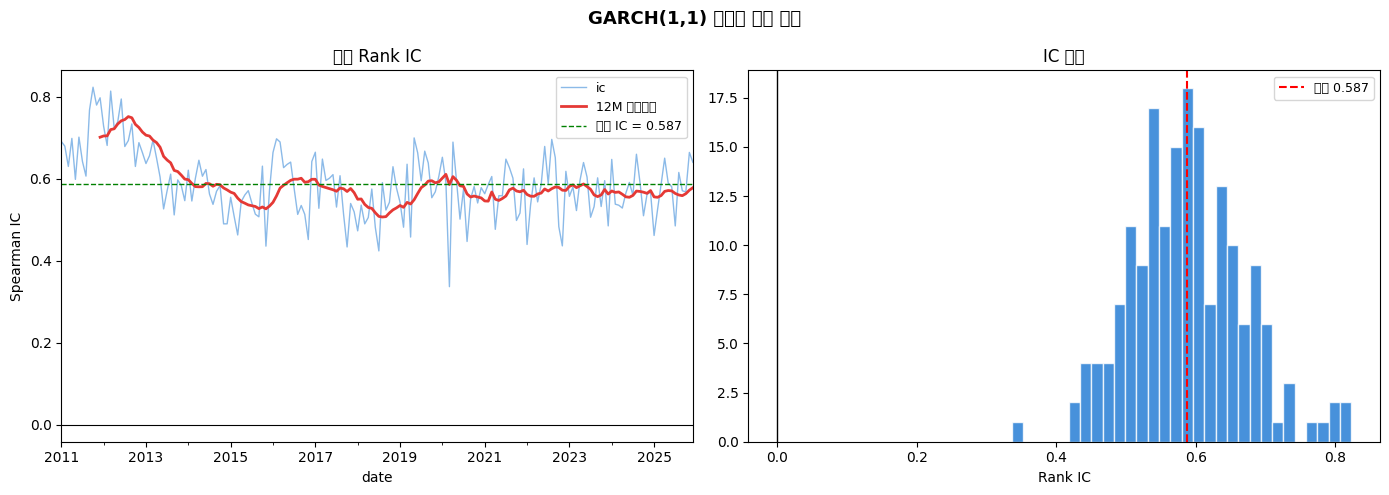

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GARCH(1,1) 변동성 예측 성능', fontsize=13, fontweight='bold')

ax = axes[0]
ic_df['ic'].plot(ax=ax, color='#1976D2', alpha=0.5, linewidth=1)
ic_df['ic'].rolling(12).mean().plot(ax=ax, color='#E53935', linewidth=2,
                                     label=f'12M 이동평균')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ic_df['ic'].mean(), color='green', linewidth=1, linestyle='--',
           label=f'평균 IC = {ic_df["ic"].mean():.3f}')
ax.set_title('월별 Rank IC')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(ic_df['ic'], bins=30, color='#1976D2', alpha=0.8, edgecolor='white')
ax.axvline(ic_df['ic'].mean(), color='red', linestyle='--',
           label=f'평균 {ic_df["ic"].mean():.3f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('IC 분포')
ax.set_xlabel('Rank IC')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'garch_rank_ic.png', dpi=150, bbox_inches='tight')
plt.show()

# 저장 확인
`cell-03`에서 GARCH 예측 완료 즉시 저장됨. 이 셀은 저장 결과를 확인한다.

출력 형식: `date, ticker, vol_pred` (long format)  
다음 단계 (`99_baseline.ipynb` GARCH 섹션)에서 이 파일을 로드해 P 행렬 분류에 사용.

In [7]:
# cell-03에서 이미 저장 완료 — 저장 결과 확인
saved = pd.read_csv(DATA_DIR / 'vol_predicted.csv', parse_dates=['date'])
print(f'vol_predicted.csv 확인')
print(f'  행수:  {len(saved):,}')
print(f'  컬럼:  {list(saved.columns)}')
print(f'  기간:  {saved["date"].min().date()} ~ {saved["date"].max().date()}')
print(f'  종목수: {saved["ticker"].nunique()}개')
print()
print(saved.head(3).to_string(index=False))

vol_predicted.csv 확인
  행수:  79,135
  컬럼:  ['date', 'ticker', 'vol_pred']
  기간:  2011-01-31 ~ 2025-12-31
  종목수: 610개

      date ticker  vol_pred
2011-01-31      A  0.414694
2011-01-31     AA  0.452712
2011-01-31   AAPL  0.352618
